## Notebook to run evaluation scripts for Different attacks

In [1]:
from attacks import *
from plonk.pipe import PlonkPipeline
from PIL import Image
import torch
import tqdm as tqdm
import matplotlib.pyplot as plt
import pandas as pd

from pipe_trajectory import PlonkPipelineTrajectory
from adversarial_utils import *
from plots_adversarial_attacks import plot_gps_samples_on_map, plot_gps_trajectories_on_map

device = torch.device("cuda")



/Data/mathias.ollu/conda_envs/plonk/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#choose pipeline

# pipeline = PlonkPipelineTrajectory("nicolas-dufour/PLONK_YFCC_diffusion").to(device)
pipeline = PlonkPipelineTrajectory("nicolas-dufour/PLONK_OSV_5M_diffusion").to(device)

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 1288.59it/s, Materializing param=vision_model.pre_layrnorm.weight]                        
CLIPVisionModel LOAD REPORT from: geolocal/StreetCLIP
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.final_layer_norm.bias                             | UNEXPECTED |  | 

In [38]:
budget=2/255

In [45]:
train_args = {"n_steps":200,
		"train_batch_size":256,
		"lr":1e-3,
		"eps_max": budget,
		"anchor_samples":512,
		"clean_num_steps":100,
		"target_pure_noise": False,
		"dot_product_loss":"absolute",
		"reconstruction_loss_weight": 0.0,
		"num_restarts" : 3,
		"restart_selection_metric": "final_step_displacement",
		"restart_eval_cfg": 10.0,
		"device": device}

In [46]:
#Choose source/target image
source_image_path = "../.media/bichkek.png"
source_image = Image.open(source_image_path)

target_image_path = "../.media/moscow.png"
target_image = Image.open(target_image_path)

In [47]:
results_diffusion = run_attack("diffusion", source_image, pipeline, **train_args)

/Data/mathias.ollu/plonk/plonk/models/samplers/ddim.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=dtype):
PGD attack training (restart 1/3): 100%|██████████| 200/200 [00:28<00:00,  6.95it/s, loss=1.893997]


[restart 1/3] final_loss=1.893997, min_loss=1.684027, mean_step_disp=nan, final_step_disp=2189.703857, selection_score=2189.703857


PGD attack training (restart 2/3): 100%|██████████| 200/200 [00:29<00:00,  6.85it/s, loss=1.696235]


[restart 2/3] final_loss=1.696235, min_loss=1.539121, mean_step_disp=nan, final_step_disp=2741.973389, selection_score=2741.973389


PGD attack training (restart 3/3): 100%|██████████| 200/200 [00:29<00:00,  6.81it/s, loss=2.041191]


[restart 3/3] final_loss=2.041191, min_loss=1.565719, mean_step_disp=nan, final_step_disp=3951.165771, selection_score=3951.165771
Selected restart 3/3 using final_step_displacement (score=3951.165771)


dict_keys(['attack_type', 'delta', 'history', 'source_tensor', 'final_loss', 'min_loss', 'config'])


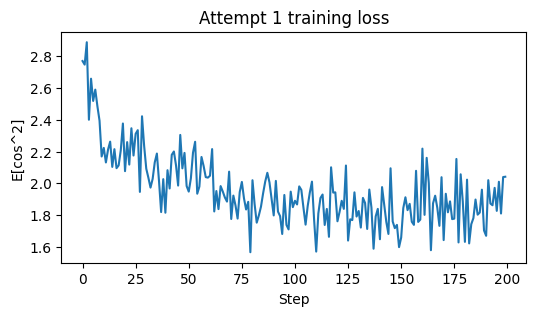

In [48]:
print(results_diffusion.keys())
delta=results_diffusion["delta"]
plt.figure(figsize=(6, 3))
plt.plot(results_diffusion["history"])
plt.title("Attempt 1 training loss")
plt.xlabel("Step")
plt.ylabel("E[cos^2]")
plt.show()

In [53]:
cfg=10
batch_size=1024
#We set a common start noise so as to compare trajectories of perturbed and non perturbed images
x_N = x_N = torch.randn(batch_size, *[3], device="cuda")
pertubed_source = add_perturbation_to_image(source_image, delta, pipeline)

gps_coords_perturbed, traj_perturbed = pipeline(pertubed_source, batch_size=batch_size, cfg=cfg,x_N=x_N, return_trajectories=True)
gps_coords_source, traj_source = pipeline(source_image, batch_size=batch_size,cfg=cfg,x_N=x_N, return_trajectories=True)

/Data/mathias.ollu/plonk/plonk/models/samplers/ddim.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=dtype):


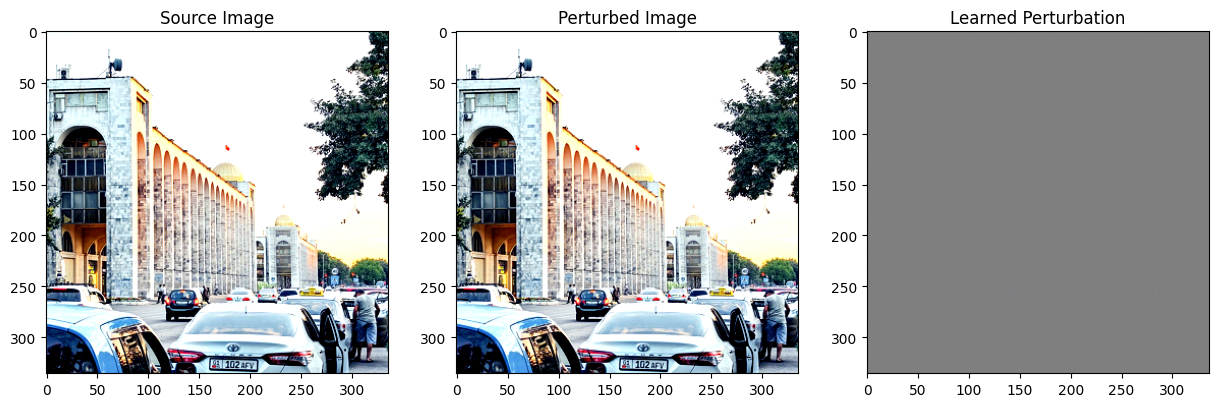

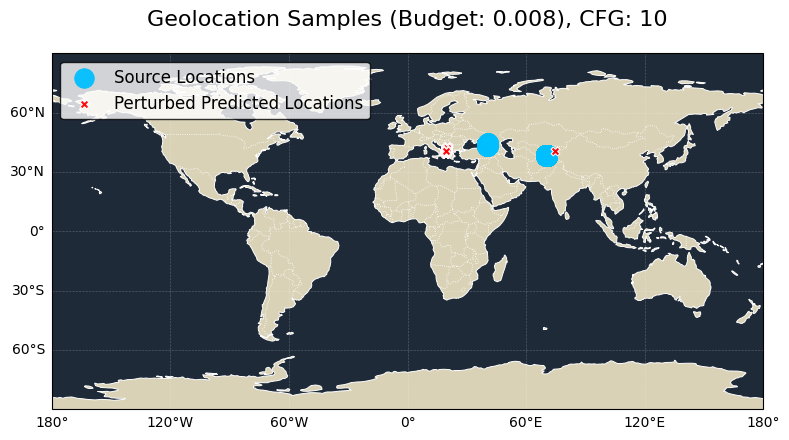

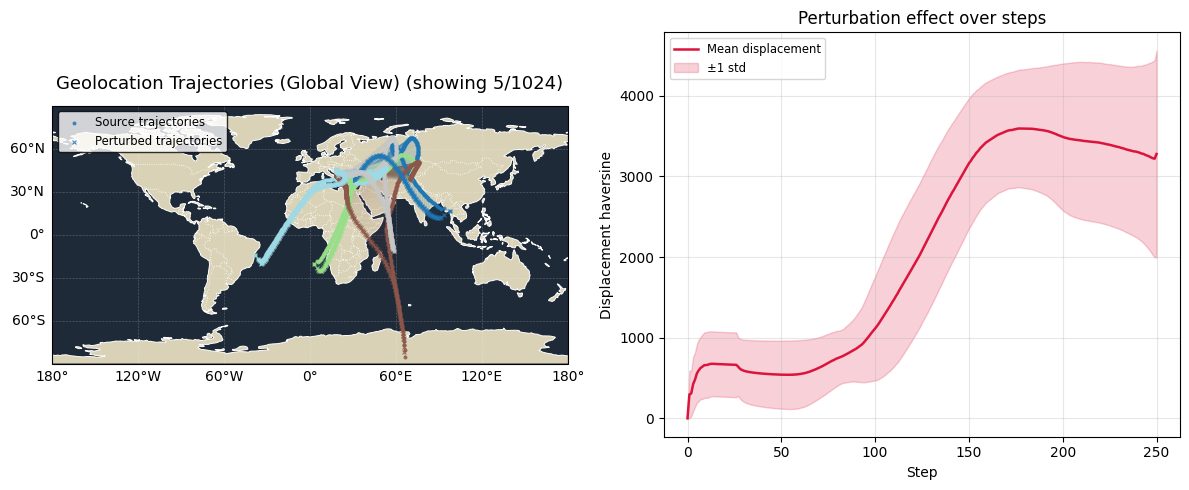

In [54]:
#plot all 3 images:
source_tensor = conditional_preprocessing(source_image, pipeline, device=device)
source_image_reformatted = tensor_to_pil(source_tensor.squeeze(0))

#convert pertubed image to PIL format:
delta_1_pil= tensor_to_pil(delta)

fig, axs = plt.subplots(1, 3, figsize=(15, 10))
axs[0].imshow(source_image_reformatted)
axs[0].set_title("Source Image")
axs[1].imshow(pertubed_source)
axs[1].set_title("Perturbed Image")
axs[2].imshow(delta_1_pil)
axs[2].set_title("Learned Perturbation")

plt.show()    

plot_gps_samples_on_map(gps_coords_source, None, gps_coords_perturbed, perturb_budget=budget, cfg=cfg, point_size=40)
plot_gps_trajectories_on_map(traj_source, traj_perturbed, show_map=True, show_paths=True,show_displacement=True, max_trajectories=5)